The goal of this project is to analyze visa application data and build a machine learning model that predicts whether a visa will be Certified or Denied based on applicant, employer, and job-related features.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [60]:
df = pd.read_csv("EasyVisa.csv")

In [61]:
df.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [62]:
df.shape

(25480, 12)

In [63]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [65]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [12]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df['annual_wage'] = df['prevailing_wage']

df.loc[df['unit_of_wage'] == 'Hourly', 'annual_wage'] = df['prevailing_wage'] * 2080
df.loc[df['unit_of_wage'] == 'Weekly', 'annual_wage'] = df['prevailing_wage'] * 52
df.loc[df['unit_of_wage'] == 'Monthly', 'annual_wage'] = df['prevailing_wage'] * 12
df.loc[df['unit_of_wage'] == 'Yearly', 'annual_wage'] = df['prevailing_wage']

In [68]:
current_year = 2026
df['company_age'] = current_year - df['yr_of_estab']

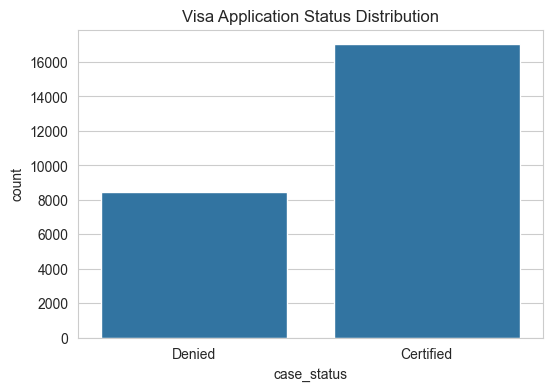

In [69]:
plt.figure(figsize=(6,4))
sns.countplot(x='case_status', data=df)
plt.title("Visa Application Status Distribution")
plt.show()

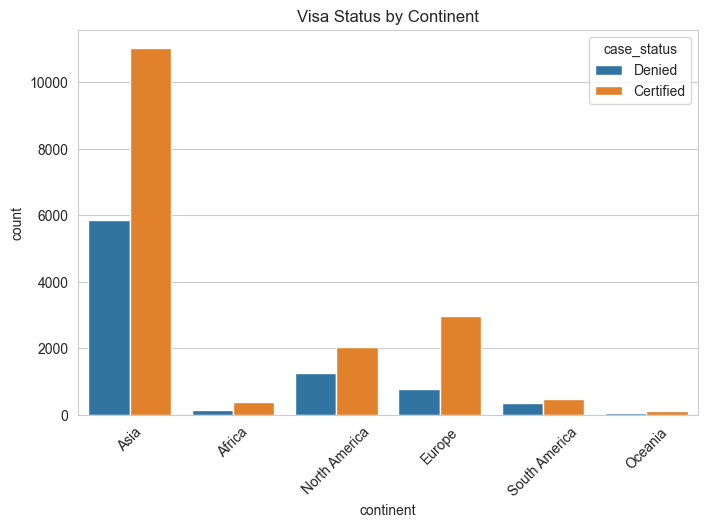

In [70]:
plt.figure(figsize=(8,5))
sns.countplot(x='continent', hue='case_status', data=df)
plt.title("Visa Status by Continent")
plt.xticks(rotation=45)
plt.show()

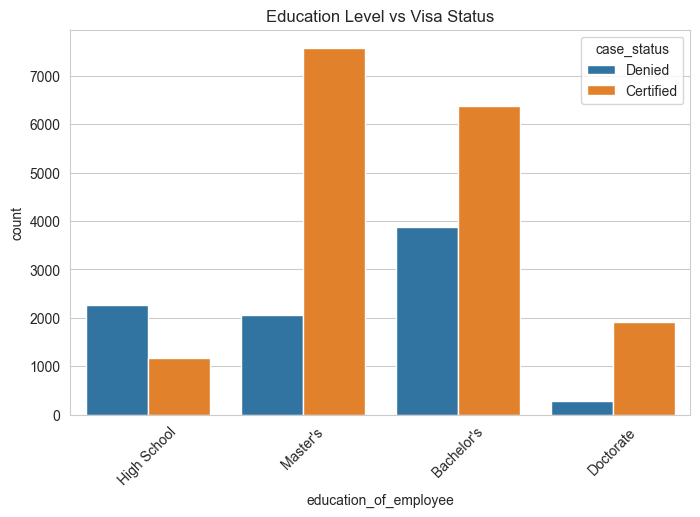

In [71]:
plt.figure(figsize=(8,5))
sns.countplot(x='education_of_employee', hue='case_status', data=df)
plt.title("Education Level vs Visa Status")
plt.xticks(rotation=45)
plt.show()

In [72]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status', 'annual_wage', 'company_age'],
      dtype='object')

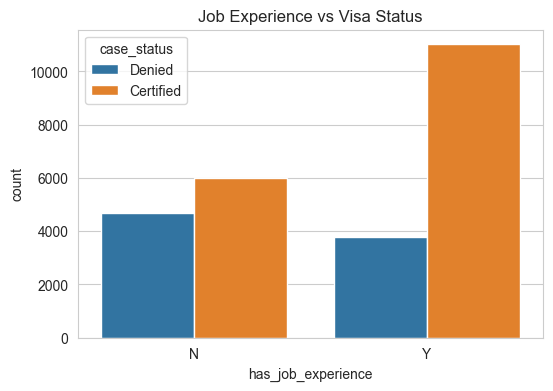

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(x='has_job_experience', hue='case_status', data=df)
plt.title("Job Experience vs Visa Status")
plt.show()

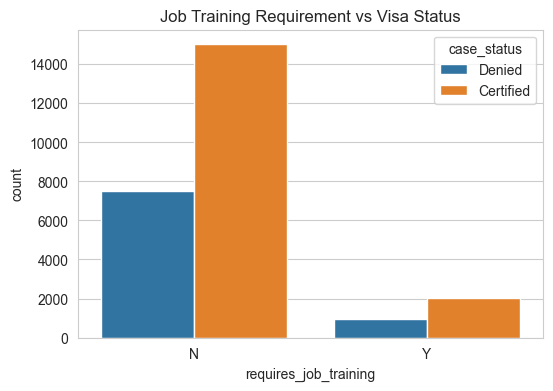

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(x='requires_job_training', hue='case_status', data=df)
plt.title("Job Training Requirement vs Visa Status")
plt.show()

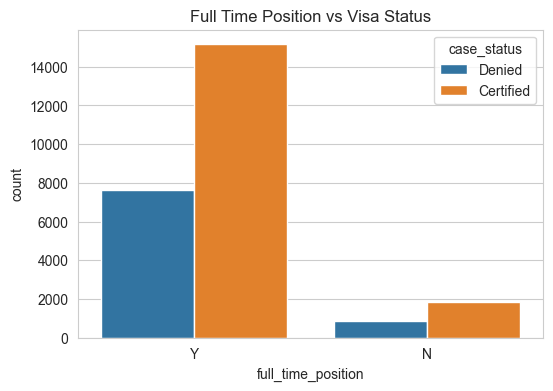

In [75]:
plt.figure(figsize=(6,4))
sns.countplot(x='full_time_position', hue='case_status', data=df)
plt.title("Full Time Position vs Visa Status")
plt.show()

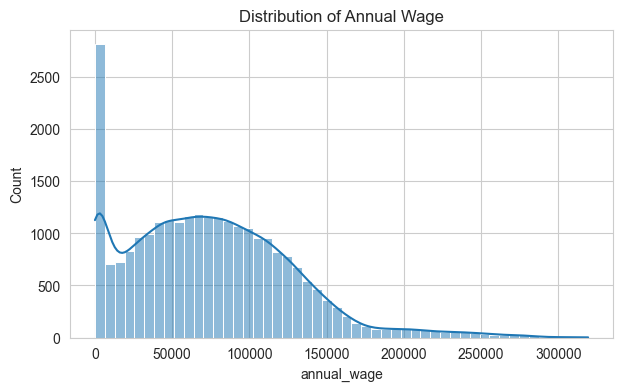

In [76]:
plt.figure(figsize=(7,4))
sns.histplot(df['annual_wage'], bins=50, kde=True)
plt.title("Distribution of Annual Wage")
plt.show()

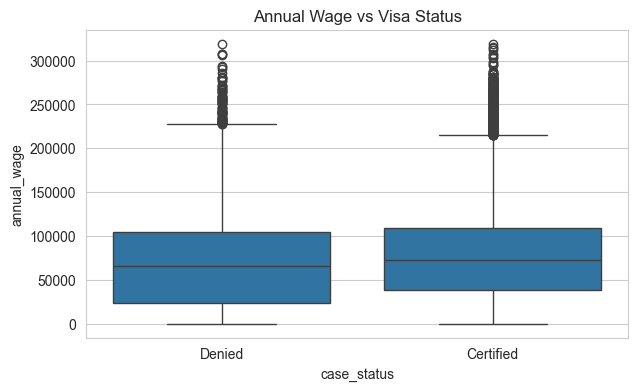

In [77]:
plt.figure(figsize=(7,4))
sns.boxplot(x='case_status', y='annual_wage', data=df)
plt.title("Annual Wage vs Visa Status")
plt.show()

In [78]:
df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [79]:
df['case_status'].value_counts(normalize=True)*100

case_status
Certified    66.789639
Denied       33.210361
Name: proportion, dtype: float64

In [80]:
df['case_status'] = df['case_status'].map({'Certified':1, 'Denied':0})

In [81]:
pd.crosstab(df['education_of_employee'], df['case_status'], normalize='index')*100

case_status,0,1
education_of_employee,,
Bachelor's,37.785812,62.214188
Doctorate,12.773723,87.226277
High School,65.964912,34.035088
Master's,21.372223,78.627777


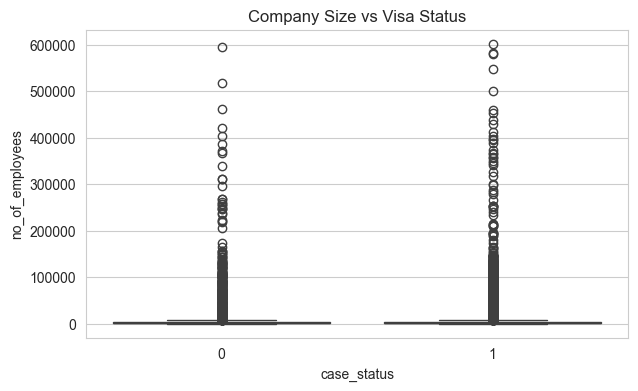

In [34]:
plt.figure(figsize=(7,4))
sns.boxplot(x='case_status', y='no_of_employees', data=df)
plt.title("Company Size vs Visa Status")
plt.show()

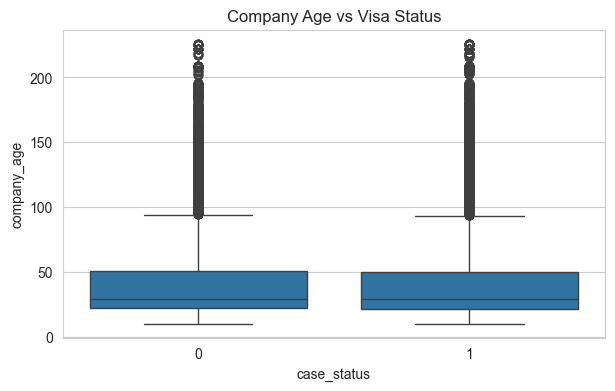

In [35]:
plt.figure(figsize=(7,4))
sns.boxplot(x='case_status', y='company_age', data=df)
plt.title("Company Age vs Visa Status")
plt.show()

In [36]:
num_df = df[['annual_wage','company_age','no_of_employees']]

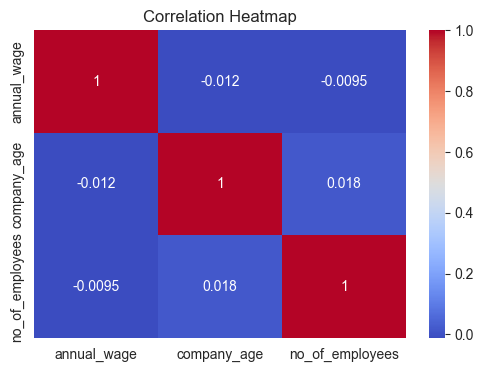

In [37]:
plt.figure(figsize=(6,4))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [38]:
approval_rate = pd.crosstab(df['continent'], df['case_status'], normalize='index') * 100

approval_rate

case_status,0,1
continent,,
Africa,27.949183,72.050817
Asia,34.689520,65.310480
Europe,20.766345,79.233655
North America,38.122722,61.877278
Oceania,36.458333,63.541667
South America,42.136150,57.863850


In [39]:
education_rate = pd.crosstab(df['education_of_employee'], df['case_status'], normalize='index') * 100

education_rate

case_status,0,1
education_of_employee,,
Bachelor's,37.785812,62.214188
Doctorate,12.773723,87.226277
High School,65.964912,34.035088
Master's,21.372223,78.627777


In [40]:
df['wage_category'] = pd.qcut(df['annual_wage'], 4, labels=['Low','Medium','High','Very High'])

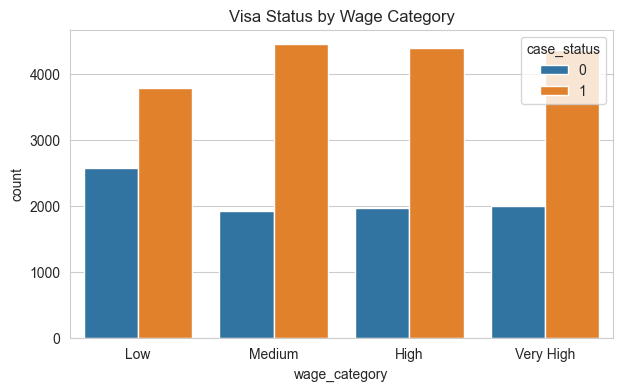

In [41]:
plt.figure(figsize=(7,4))
sns.countplot(x='wage_category', hue='case_status', data=df)
plt.title("Visa Status by Wage Category")
plt.show()

In [42]:
df.groupby('continent')['annual_wage'].mean().sort_values(ascending=False)

continent
Asia             79543.021780
Africa           77425.923450
Oceania          75994.276719
North America    68066.319257
South America    60209.575314
Europe           59842.925899
Name: annual_wage, dtype: float64

In [56]:
df.head(10)

,no_of_employees,case_status,annual_wage,company_age,case_id_EZYV02,case_id_EZYV03,case_id_EZYV04,case_id_EZYV05,case_id_EZYV06,case_id_EZYV07,...,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,full_time_position_Y,wage_category_Medium,wage_category_High,wage_category_Very High
0,14513,0,592.2029,19,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
1,2412,1,83425.6500,24,True,False,False,False,False,False,...,True,False,False,True,False,False,True,False,True,False
2,44444,0,122996.8600,18,False,True,False,False,False,False,...,False,True,False,False,False,True,True,False,False,True
3,98,0,83434.0300,129,False,False,True,False,False,False,...,False,False,False,False,False,True,True,False,True,False
4,1082,1,149907.3900,21,False,False,False,True,False,False,...,True,False,False,False,True,False,True,False,False,True
5,2339,1,78252.1400,14,False,False,False,False,True,False,...,True,False,False,False,True,False,True,False,True,False
6,4985,1,53635.3900,32,False,False,False,False,False,True,...,False,False,False,False,True,False,True,True,False,False
7,3035,0,418.2298,102,False,False,False,False,False,False,...,True,False,False,False,False,True,True,False,False,False
8,4810,1,74362.1900,14,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
9,2251,1,67514.7600,31,False,False,False,False,False,False,...,True,False,False,False,True,False,True,True,False,False


In [44]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status', 'annual_wage', 'company_age',
       'wage_category'],
      dtype='object')

In [45]:
df.drop('prevailing_wage', axis=1, inplace=True)

In [46]:
df.drop('unit_of_wage', axis=1, inplace=True)

In [47]:
df.drop('yr_of_estab', axis=1, inplace=True)

In [48]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'region_of_employment',
       'full_time_position', 'case_status', 'annual_wage', 'company_age',
       'wage_category'],
      dtype='object')

In [50]:
df.head(11)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,case_status,annual_wage,company_age,wage_category
0,EZYV01,Asia,High School,N,N,14513,West,Y,0,592.2029,19,Low
1,EZYV02,Asia,Master's,Y,N,2412,Northeast,Y,1,83425.6500,24,High
2,EZYV03,Asia,Bachelor's,N,Y,44444,West,Y,0,122996.8600,18,Very High
3,EZYV04,Asia,Bachelor's,N,N,98,West,Y,0,83434.0300,129,High
4,EZYV05,Africa,Master's,Y,N,1082,South,Y,1,149907.3900,21,Very High
5,EZYV06,Asia,Master's,Y,N,2339,South,Y,1,78252.1400,14,High
6,EZYV07,Asia,Bachelor's,N,N,4985,South,Y,1,53635.3900,32,Medium
7,EZYV08,North America,Bachelor's,Y,N,3035,West,Y,0,418.2298,102,Low
8,EZYV09,Asia,Bachelor's,N,N,4810,Midwest,Y,1,74362.1900,14,High
9,EZYV10,Europe,Doctorate,Y,N,2251,South,Y,1,67514.7600,31,Medium


In [51]:
df['annual_wage'].describe()

count     25480.000000
mean      74455.814592
std       52815.942327
min           2.136700
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: annual_wage, dtype: float64

<Axes: ylabel='annual_wage'>

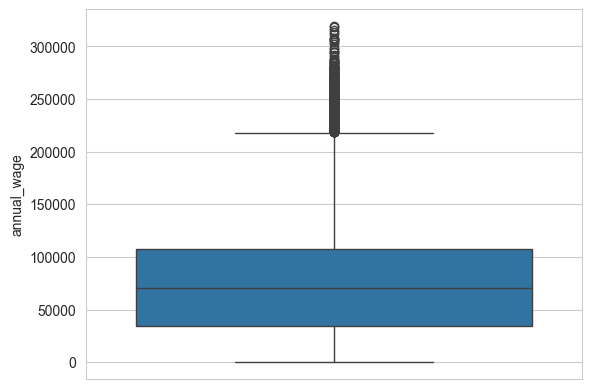

In [52]:
sns.boxplot(df['annual_wage'])

In [53]:
df['case_status'].value_counts(normalize=True)

case_status
1    0.667896
0    0.332104
Name: proportion, dtype: float64

In [57]:
df[df['annual_wage'] < 1000]

,no_of_employees,case_status,annual_wage,company_age,case_id_EZYV02,case_id_EZYV03,case_id_EZYV04,case_id_EZYV05,case_id_EZYV06,case_id_EZYV07,...,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,full_time_position_Y,wage_category_Medium,wage_category_High,wage_category_Very High
0,14513,0,592.2029,19,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
7,3035,0,418.2298,102,False,False,False,False,False,False,...,True,False,False,False,False,True,True,False,False,False
54,11733,1,230.8072,31,False,False,False,False,False,False,...,True,False,False,True,False,False,True,False,False,False
62,5110,0,103.2216,22,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
70,1320,0,230.3270,25,False,False,False,False,False,False,...,True,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25444,1081,1,156.6070,188,False,False,False,False,False,False,...,True,False,False,True,False,False,True,False,False,False
25450,3312,0,682.1048,17,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
25461,2861,0,54.9196,22,False,False,False,False,False,False,...,True,False,False,False,False,True,True,False,False,False
25465,2577,1,481.2238,31,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
